## Simulate a New Model

Predict *only* interpretable metabolic parameters *r_A* and *r_I*. Fix *C_0* small and *x_0* to be something. Fit only in regime II, maybe do this by excluding the rightmost column only for now. 

In [28]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from mgsa.io import get_function, samples_from_soils
from mgsa.helpers import plot, plot10

In [29]:
def timestep(rhs, y_n, params, dt):
    """RK4 timestep
    
    Args:
        rhs (callable): Right hand side derivative function dy/condt. Should return
            an array of length d.
            
        y_n (np.ndarray[float]): Current state. Length d.
        params (list): variable length list of parameters.
        dt (float): stepsize.
    
    Returns:
        (np.ndarray) array of length d, the updated state, using RK4.
    """
    k_1 = rhs(y_n, params)
    k_2 = rhs(y_n + dt*k_1/2, params)
    k_3 = rhs(y_n + dt*k_2/2, params)
    k_4 = rhs(y_n + dt*k_3, params)
    y_new = y_n + (dt/6) * (k_1 + 2*k_2 + 2*k_3 + k_4)
    return y_new


def simulate(rhs, y0, params, dt, T):
    """Simulate an ODE from an initial condition over a specified interval.
    
    Args:
        rhs (callable): Right hand side derivative function dy/dt. Should return
            an array of length d.
        y0 (np.ndarray[float]): Initial condition. Length d.
        params (list): variable length list of parameters.
        dt (float): stepsize.
        T (float): final time.
    
    Returns:
        (np.ndarray) Array of shape (d, N). The state history over the interval.
    """
    N = int(T/dt)
    d = len(y0)
    ys = np.zeros([d, N])
    ys[:,0] = y0
    y = ys[:,0]
    for i in range(N-1):
        y_new = timestep(rhs, y, params, dt)
        ys[:, i + 1] = y_new
        y = y_new
    return ys

This is the model

\begin{align}
    \dot{x} &= \gamma x \bigg[ \frac{A}{K_A + A} + \frac{I}{K_I + I} \bigg]\frac{C}{K_C + C}\\
    \dot{A} &= -r_A x \frac{A}{K_A + A}\\
    \dot{I} &= r_A x \frac{A}{K_A + A} - r_I x \frac{I}{K_I + I}\\
    \dot{C} &= -x \frac{C}{K_C + C}
\end{align}

In [87]:
def RHS(y, params):
    x, A, I, C = y
    r_A, r_I, gamma_A, gamma_I, K_A, K_I, K_C = params

    dx = (gamma_A*r_A*A/(K_A + A) + gamma_I*r_I*I/(K_I + I))*x*C/(K_C + C)
    dA = -r_A*x*A/(K_A + A)
    dI = (r_A*A/(K_A + A) - r_I*I/(K_I + I))*x
    dC = - x*C/(K_C + C)
    
    dydt = np.array([dx, dA, dI, dC])
    return dydt


### no fitting of gamma

native:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

...

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

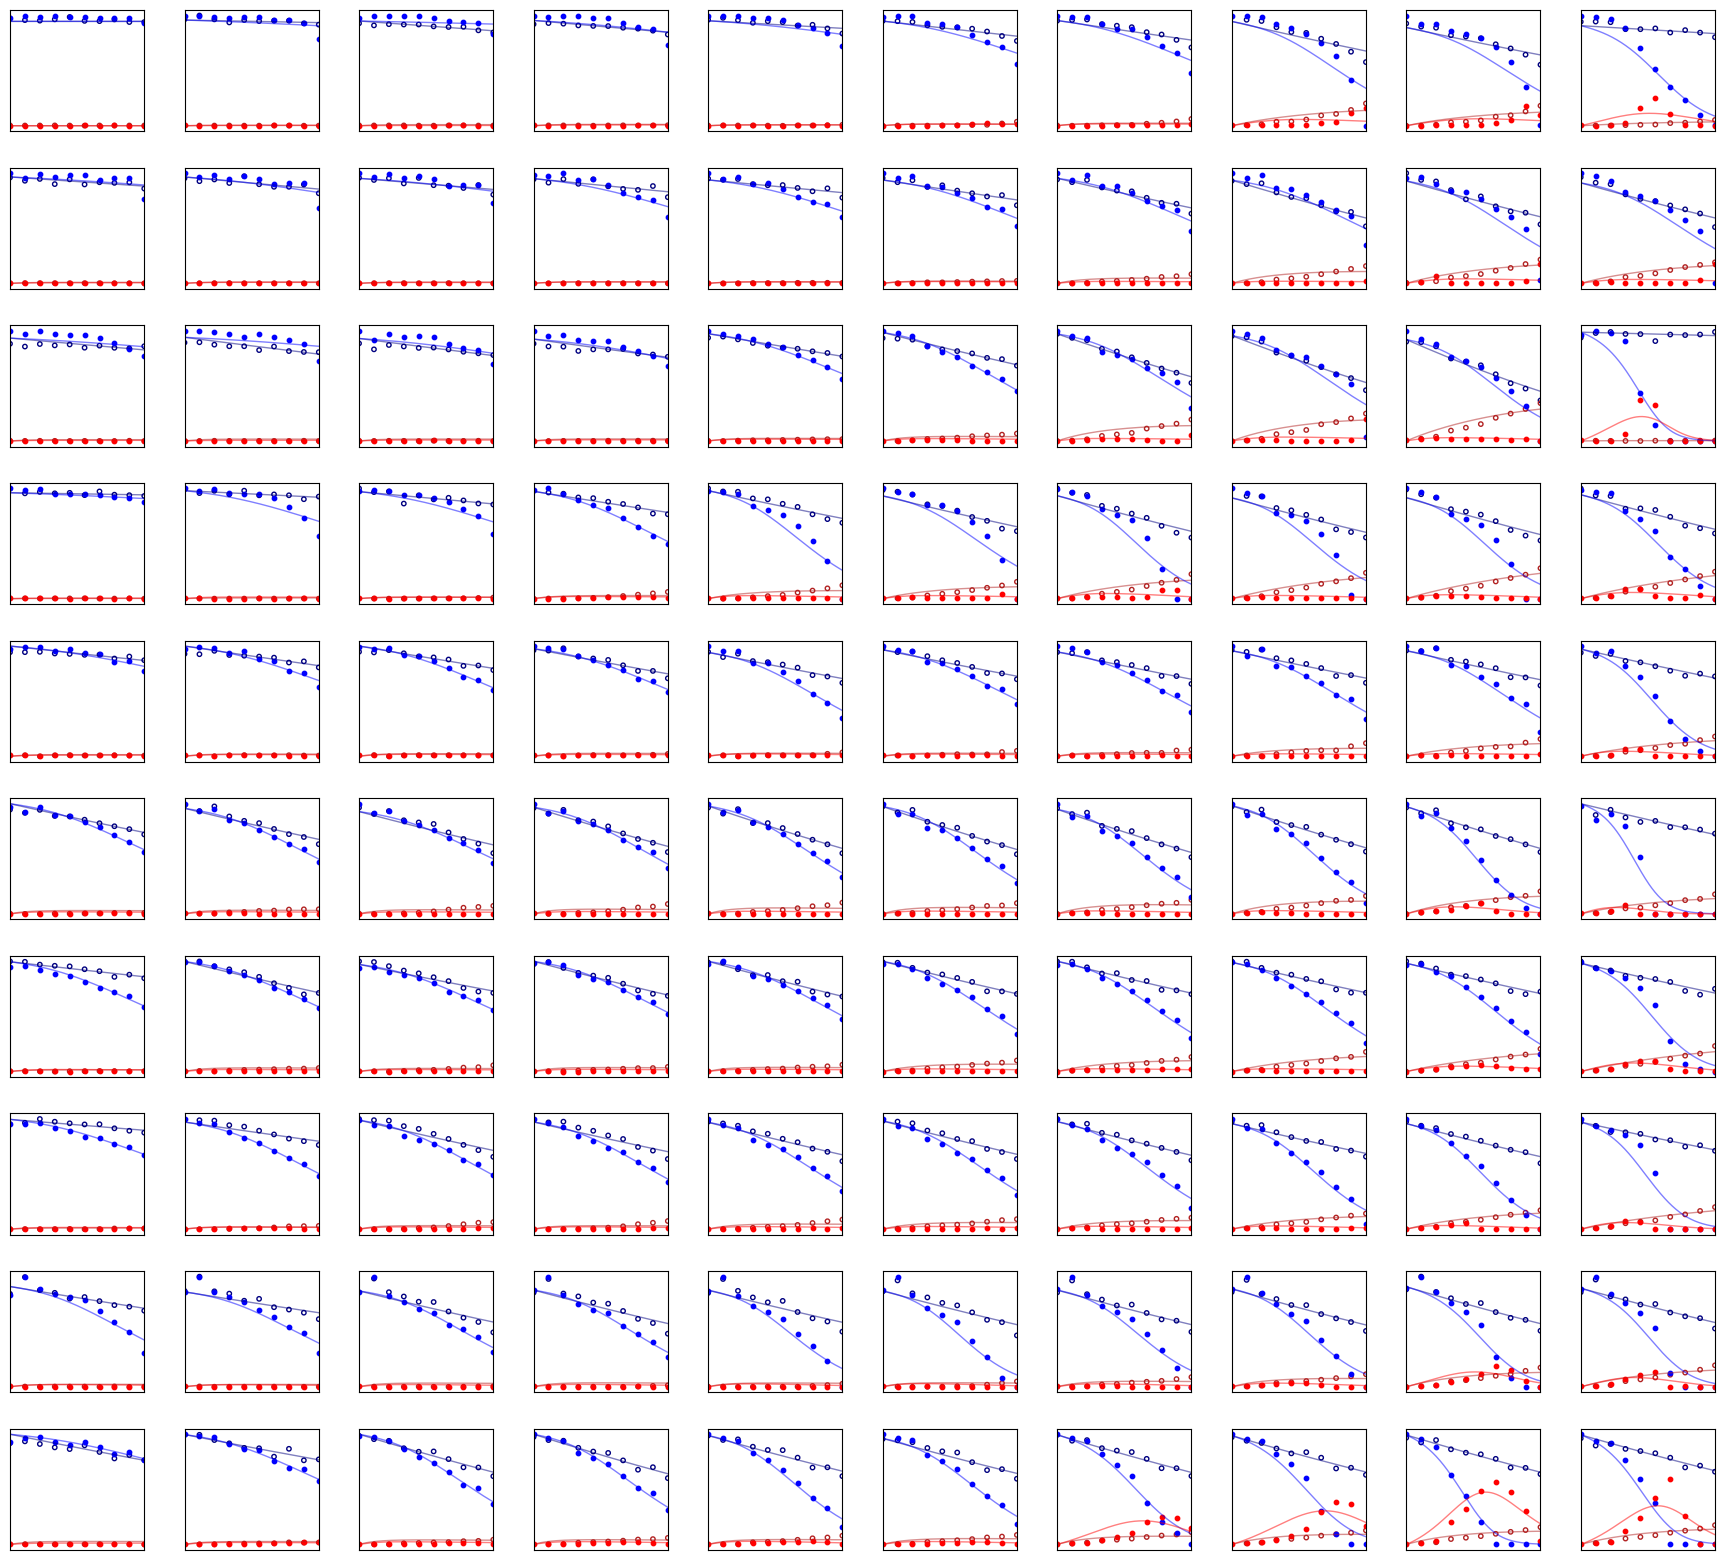

In [109]:
import tqdm.notebook as tqdm
fig, axs = plt.subplots(10, 10, figsize=(22, 20))
plt.subplots_adjust(hspace=0.3, wspace=0.3)


t_data = np.linspace(0, 19, 20)
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 
         'Soil15', 'Soil16', 'Soil17']

A_0 = 2
I_0 = 0
K_A = 1
K_I = 1
K_C = 1
dt = 0.05
T = 9

gamma_A = 5
gamma_I = 5

#select these with a global fit? 
x_0 = 0.1
C_0 = 0.1

N = int(T/dt)

#rA and rA drug should not be the same. Why? Nonuniform growth of different variants will change the reduction rate. 

param_values = np.zeros((10,10,4))

for native in tqdm.trange(10, desc = 'native'): 
    for pert in tqdm.trange(10, desc = 'pert'):  

        sample = samples_from_soils(soils[9 - native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        I_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
            I_data_drug += function[i + 3]
        A_data_drug = A_data_drug/3
        I_data_drug = I_data_drug/3
        y_data_drug = np.concatenate([A_data_drug, I_data_drug])
        
        function = get_function(sample)
        A_data = np.zeros(10)
        I_data = np.zeros(10)
        for i in range(3):
            A_data += function[i]
            I_data += function[i + 3]
        A_data = A_data/3
        I_data = I_data/3
        y_data = np.concatenate([A_data, I_data])
        
        
        def model_drug(t, r_A, r_I):
            indices = np.linspace(0, int(9/dt-1), 10).astype(int)

            y0 = np.array([x_0, A_0, I_0, C_0])
            params = [r_A, r_I, 0, 0, K_A, K_I, K_C]
            _, A, I, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            I_out = I[indices]
            return np.concatenate([A_out, I_out])
        
        
        initial_guess = [1, 1]
        bounds = ([0.001, 0.001], [10, 10])
        
        popt, pcov = curve_fit(model_drug, t_data, y_data_drug, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][0] = popt[0]
        param_values[native, pert][1] = popt[1]

        y0 = np.array([x_0, A_0, I_0, C_0])
        params = [popt[0], popt[1], 0, 0,  K_A, K_I, K_C]
        x, A, I, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        t_scatter = np.linspace(0, 9, 10)
        
        ax = axs[native, pert]
        ax.plot(t, A, color='navy', alpha=0.5, linewidth=1)
        ax.plot(t, I, color='firebrick', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, A_data_drug, color='navy', s=10, facecolors = 'none')
        ax.scatter(t_scatter, I_data_drug, color='firebrick', s=10, facecolors = 'none')
        
        def model(t, r_A, r_I):
            indices = np.linspace(0, int(9/dt-1), 10).astype(int)

            y0 = np.array([x_0, A_0, I_0, C_0])
            params = [r_A, r_I, gamma_A, gamma_I, K_A, K_I, K_C]
            _, A, I, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            I_out = I[indices]
            return np.concatenate([A_out, I_out])
        
        initial_guess = [1, 1]
        bounds = ([0.001, 0.001], [10, 10])
        
        popt, pcov = curve_fit(model, t_data, y_data, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][2] = popt[0]
        param_values[native, pert][3] = popt[1]

        y0 = np.array([x_0, A_0, I_0, C_0])
        params = [popt[0], popt[1], gamma_A, gamma_I, K_A, K_I, K_C]
        x, A, I, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        t_scatter = np.linspace(0, 9, 10)
        
        ax = axs[native, pert]
        ax.plot(t, A, color='Blue', alpha=0.5, linewidth=1)
        ax.plot(t, I, color='Red', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, A_data, color='Blue', s=10)
        ax.scatter(t_scatter, I_data, color='Red', s=10)
        
        ax.set_xlim(0, 9)
        
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.show()

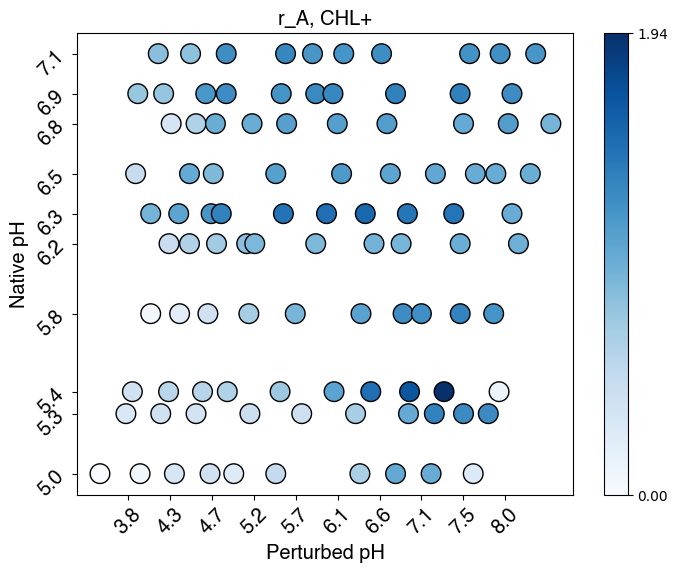

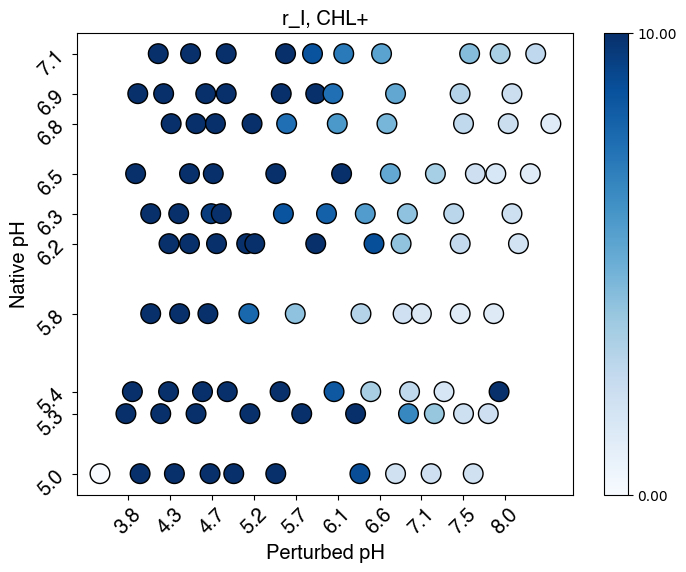

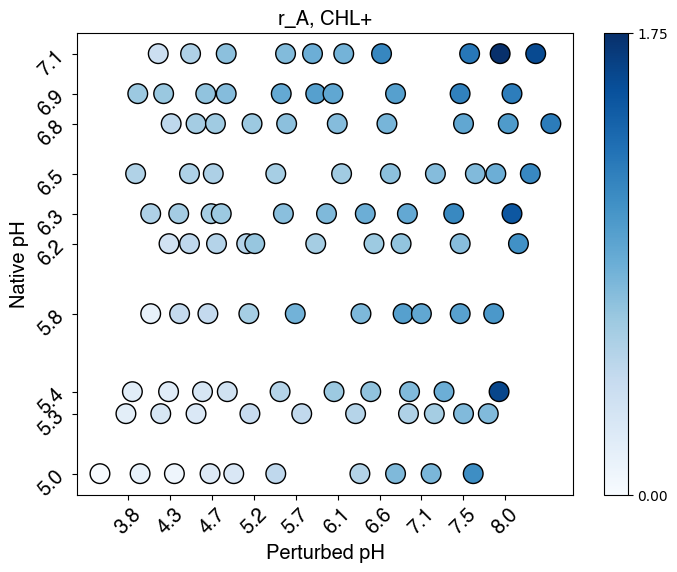

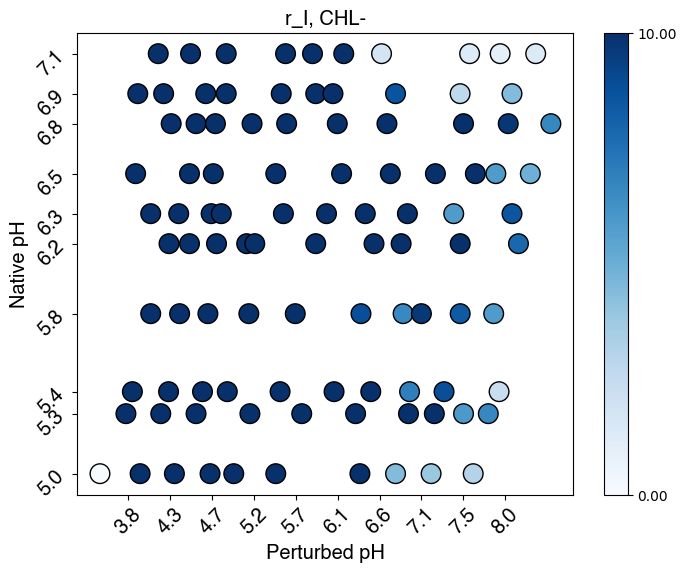

In [110]:
plot10(param_values[:,:,0], 'r_A, CHL+')
plot10(param_values[:,:,1], 'r_I, CHL+')
plot10(param_values[:,:,2], 'r_A, CHL+')
plot10(param_values[:,:,3], 'r_I, CHL-')

np.savetxt(f"../out/metabolic_parameters/rA_drug_model1_chl_pos.tsv", param_values[:,:,0], delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/metabolic_parameters/rI_drug_model1_chl_pos.tsv", param_values[:,:,1], delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/metabolic_parameters/rA_none_model1_chl_pos.tsv", param_values[:,:,2], delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/metabolic_parameters/rI_none_model1_chl_neg.tsv", param_values[:,:,3], delimiter = '\t', fmt = '%0.6f')

rA_drug = param_values[:,:,0]
rI_drug = param_values[:,:,1]
rA = param_values[:,:,2]
rI = param_values[:,:,3]

### Perform a global fit for initial conditions. 

In [91]:
A_0 = 2
I_0 = 0
dt = 0.05
T = 9


N = int(T/dt)

#first, collect the data in length 2000 arrays 

data_drug = []
data = []
for native in tqdm.trange(10, desc = 'native'): 
    for pert in tqdm.trange(10, desc = 'pert'):  

        sample = samples_from_soils(soils[9 - native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        I_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
            I_data_drug += function[i + 3]
        A_data_drug = A_data_drug/3
        I_data_drug = I_data_drug/3
        y_data_drug = np.concatenate([A_data_drug, I_data_drug])
        data_drug = np.concatenate([data_drug, y_data_drug])
        
        function = get_function(sample)
        A_data = np.zeros(10)
        I_data = np.zeros(10)
        for i in range(3):
            A_data += function[i]
            I_data += function[i + 3]
        A_data = A_data/3
        I_data = I_data/3
        y_data = np.concatenate([A_data, I_data])
        data = np.concatenate([data, y_data])
        
total_data = np.concatenate([data_drug, data])




native:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

...

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

In [99]:
def model(t, x0, C0, gamma):
    out_drug = []
    out = []
    for nat in range(10):
        for pert in range(10):
            indices = np.linspace(0, int(9/dt-1), 10).astype(int)
            y0 = np.array([x0, A_0, I_0, C0])
            params = [rA_drug[nat, pert], rI_drug[nat, pert], 0, 0, K_A, K_I, K_C]
            _, A, I, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            I_out = I[indices]
            y_out_drug = np.concatenate([A_out, I_out])
            out_drug = np.concatenate([out_drug, y_out_drug])
            
            params = [rA[nat, pert], rI[nat, pert], gamma, gamma, K_A, K_I, K_C]
            _, A, I, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            I_out = I[indices]
            y_out = np.concatenate([A_out, I_out])
            out = np.concatenate([out, y_out])
    return np.concatenate([out_drug, out])

# initial_guess = [1, 0.001]
# bounds = ([0.0001, 0.001], [10, 10])
        
        
# popt, pcov = curve_fit(model, np.zeros(4000), total_data, 
#                         p0=initial_guess, 
#                         bounds=bounds,
#                         maxfev=100000)


print('x0 =', popt[0], 'c0 = ', popt[1])

#manual curve fit. 

def euclidean_distance(list1, list2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(list1, list2)))

space = np.linspace(0.0001, 0.1, 5)
gamma_space = np.linspace(0.1, 10, 5)
for g in gamma_space:
    for x in space:
        for c in space: 
            prediction = model(0, x, c, g)
            error = euclidean_distance(prediction, total_data)
            print('error x = ', x, 'c = ', c, 'gamma = ', g, 'error is ', error, '\n')

x0 = 1.5705487788912713 c0 =  1.3527701395506837
error x =  0.0001 c =  0.0001 gamma =  0.1 error is  26.529140759728183 

error x =  0.0001 c =  0.025075 gamma =  0.1 error is  26.52909233070141 

error x =  0.0001 c =  0.050050000000000004 gamma =  0.1 error is  26.529045788863428 

error x =  0.0001 c =  0.07502500000000001 gamma =  0.1 error is  26.529001026849432 

error x =  0.0001 c =  0.1 gamma =  0.1 error is  26.52895794521864 

error x =  0.025075 c =  0.0001 gamma =  0.1 error is  23.314507643332927 

error x =  0.025075 c =  0.025075 gamma =  0.1 error is  23.300641422938565 

error x =  0.025075 c =  0.050050000000000004 gamma =  0.1 error is  23.287218624241426 

error x =  0.025075 c =  0.07502500000000001 gamma =  0.1 error is  23.274219936220987 

error x =  0.025075 c =  0.1 gamma =  0.1 error is  23.26162705374637 

error x =  0.050050000000000004 c =  0.0001 gamma =  0.1 error is  20.498392155790988 

error x =  0.050050000000000004 c =  0.025075 gamma =  0.1 error